# NLP Preprocessing Pipeline
**End-to-end pipeline:** Kaggle download → EDA → Text Cleaning → BERT Tokenization → Stratified Split → Export

---

## 0. Setup & Dependencies

In [40]:
# Install required packages (run once)
# !pip install kaggle transformers datasets scikit-learn pandas matplotlib seaborn wordcloud

In [41]:
import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import kagglehub
import pandas as pd

from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from datasets import Dataset, DatasetDict

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 1. Configuration

In [42]:
# ─── USER CONFIG ──────────────────────────────────────────────────────────────
KAGGLE_DATASET   = 'nn_final/sentiment140'   # <-- change to your dataset slug
TEXT_COL         = 'statement'                    # column with raw text
LABEL_COL        = 'status'               # column with class labels
BERT_MODEL       = 'bert-base-uncased'       # any HuggingFace tokenizer
MAX_LENGTH       = 128                       # token truncation length

TRAIN_RATIO      = 0.70
VAL_RATIO        = 0.15
TEST_RATIO       = 0.15
RANDOM_STATE     = 42

DATA_DIR         = Path('data')
OUTPUT_DIR       = Path('output')
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9, 'Ratios must sum to 1.0'
print(f'Config loaded  |  dataset: {KAGGLE_DATASET}  |  model: {BERT_MODEL}  |  max_len: {MAX_LENGTH}')

Config loaded  |  dataset: nn_final/sentiment140  |  model: bert-base-uncased  |  max_len: 128


## 2. Download Dataset from Kaggle

In [43]:
# Download latest version
path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")

files = os.listdir(path=path)

df = pd.read_csv(os.path.join(path, files[0]))

In [44]:
print(f'Shape : {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Shape : (53043, 3)
Columns: ['Unnamed: 0', 'statement', 'status']


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety


In [45]:
# ── Normalise to (text, label) if needed ──────────────────────────────────────
# Map numeric labels → readable strings  (edit to match your dataset)
LABEL_MAP = {0: 'negative', 2: 'neutral', 4: 'positive'}

df = df[[TEXT_COL, LABEL_COL]].copy()
if df[LABEL_COL].dtype != object:
    df[LABEL_COL] = df[LABEL_COL].map(LABEL_MAP).fillna(df[LABEL_COL].astype(str))

print(f'Working dataframe: {df.shape}')
print(f'Label values     : {sorted(df[LABEL_COL].unique())}')
df.head(3)

Working dataframe: (53043, 2)
Label values     : ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety


## 3. Exploratory Data Analysis

### 3.1 Class Distribution

In [46]:
label_counts = df[LABEL_COL].value_counts().sort_index()
label_pct    = label_counts / len(df) * 100

print('Class distribution')
print('─' * 38)
for cls, cnt in label_counts.items():
    bar = '█' * int(label_pct[cls] / 2)
    print(f'{str(cls):>12}  {cnt:>8,}  ({label_pct[cls]:5.1f}%)  {bar}')
print('─' * 38)
print(f'{"TOTAL":>12}  {len(df):>8,}  (100.0%)')

# Imbalance ratio
imbalance = label_counts.max() / label_counts.min()
print(f'\nImbalance ratio (max/min): {imbalance:.2f}x')
if imbalance > 2:
    print('⚠  Consider class-weighting or oversampling during training.')

Class distribution
──────────────────────────────────────
     Anxiety     3,888  (  7.3%)  ███
     Bipolar     2,877  (  5.4%)  ██
  Depression    15,404  ( 29.0%)  ██████████████
      Normal    16,351  ( 30.8%)  ███████████████
Personality disorder     1,201  (  2.3%)  █
      Stress     2,669  (  5.0%)  ██
    Suicidal    10,653  ( 20.1%)  ██████████
──────────────────────────────────────
       TOTAL    53,043  (100.0%)

Imbalance ratio (max/min): 13.61x
⚠  Consider class-weighting or oversampling during training.


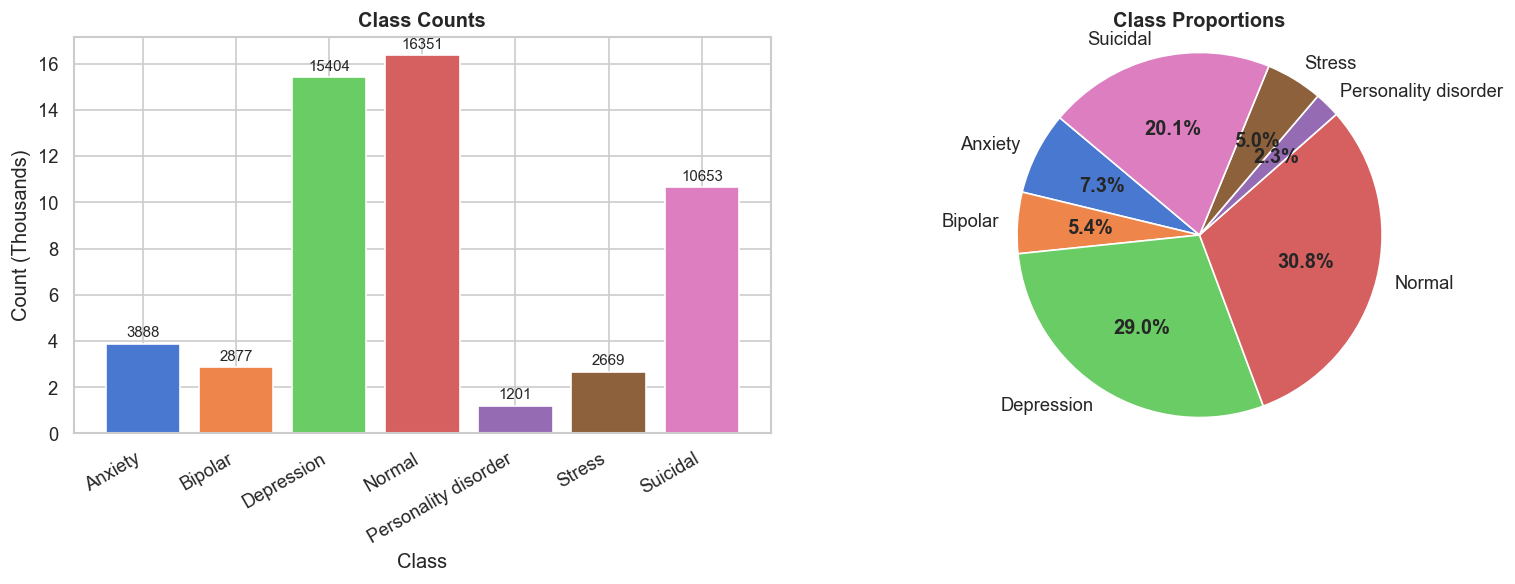

In [47]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5),                     # slightly wider overall figure
    gridspec_kw={'width_ratios': [1, 1.3]}  # give pie chart more space
)

# Bar chart
axes[0].bar(
    label_counts.index.astype(str),
    label_counts.values,
    color=sns.color_palette('muted', len(label_counts)),
    edgecolor='white'
)

axes[0].set_title('Class Counts', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count (Thousands)')
axes[0].tick_params(axis='x', rotation=30)
for label in axes[0].get_xticklabels():
    label.set_ha('right')

axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}')
)

for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + len(df)*0.003,
        f'{bar.get_height()}',
        ha='center',
        va='bottom',
        fontsize=9
    )

wedges, texts, autotexts = axes[1].pie(
    label_counts.values,
    labels=label_counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=140,
    radius=1.15,  
    textprops={'fontsize': 11},
    colors=sns.color_palette('muted', len(label_counts))
)

# Make percentage labels larger + bold
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

axes[1].set_title('Class Proportions', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', bbox_inches='tight')
plt.show()

### 3.2 Missing Values

In [48]:
missing = df.isnull().sum()
missing_pct = missing / len(df) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %':     missing_pct.round(4)
})
print('Missing value audit')
print(missing_df.to_string())

empty_text = (df[TEXT_COL].astype(str).str.strip() == '').sum()
print(f'\nEmpty / whitespace-only text rows: {empty_text:,}')

Missing value audit
           Missing Count  Missing %
statement            362     0.6825
status                 0     0.0000

Empty / whitespace-only text rows: 0


In [49]:
# Drop rows with missing text or label
before = len(df)
df.dropna(subset=[TEXT_COL, LABEL_COL], inplace=True)
df = df[df[TEXT_COL].astype(str).str.strip() != ''].copy()
df.reset_index(drop=True, inplace=True)
print(f'Rows removed (missing): {before - len(df):,}  |  Remaining: {len(df):,}')

Rows removed (missing): 362  |  Remaining: 52,681


### 3.3 Duplicate Detection

In [50]:
n_exact_dup    = df.duplicated(subset=[TEXT_COL]).sum()
n_full_dup     = df.duplicated().sum()
n_cross_label  = df[df.duplicated(subset=[TEXT_COL], keep=False)] \
                   .groupby(TEXT_COL)[LABEL_COL].nunique()
n_conflict     = (n_cross_label > 1).sum()

print(f'Duplicate text rows (same text, any label) : {n_exact_dup:,}')
print(f'Fully duplicate rows (text + label)        : {n_full_dup:,}')
print(f'Conflicting label rows (same text, diff lbl): {n_conflict:,}')

if n_conflict > 0:
    print('\n⚠  Conflicting labels — showing top 5 examples:')
    conflict_texts = n_cross_label[n_cross_label > 1].index[:5]
    print(df[df[TEXT_COL].isin(conflict_texts)][[TEXT_COL, LABEL_COL]].to_string())

Duplicate text rows (same text, any label) : 1,608
Fully duplicate rows (text + label)        : 1,588
Conflicting label rows (same text, diff lbl): 18

⚠  Conflicting labels — showing top 5 examples:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [51]:
# Remove exact duplicates (keep first occurrence)
before = len(df)
df.drop_duplicates(subset=[TEXT_COL], keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Rows removed (duplicates): {before - len(df):,}  |  Remaining: {len(df):,}')

Rows removed (duplicates): 1,608  |  Remaining: 51,073


### 3.4 Text Length Statistics

In [52]:
df['char_len']  = df[TEXT_COL].str.len()
df['word_len']  = df[TEXT_COL].str.split().str.len()

stats = df[['char_len', 'word_len']].describe(percentiles=[.25, .5, .75, .90, .95, .99])
print('Text length statistics')
print(stats.round(1).to_string())

Text length statistics
       char_len  word_len
count   51073.0   51073.0
mean      575.4     112.7
std       847.7     164.1
min         2.0       1.0
25%        79.0      15.0
50%       313.0      61.0
75%       745.0     147.0
90%      1414.0     278.0
95%      2017.0     395.0
99%      3787.3     734.0
max     32759.0    6300.0


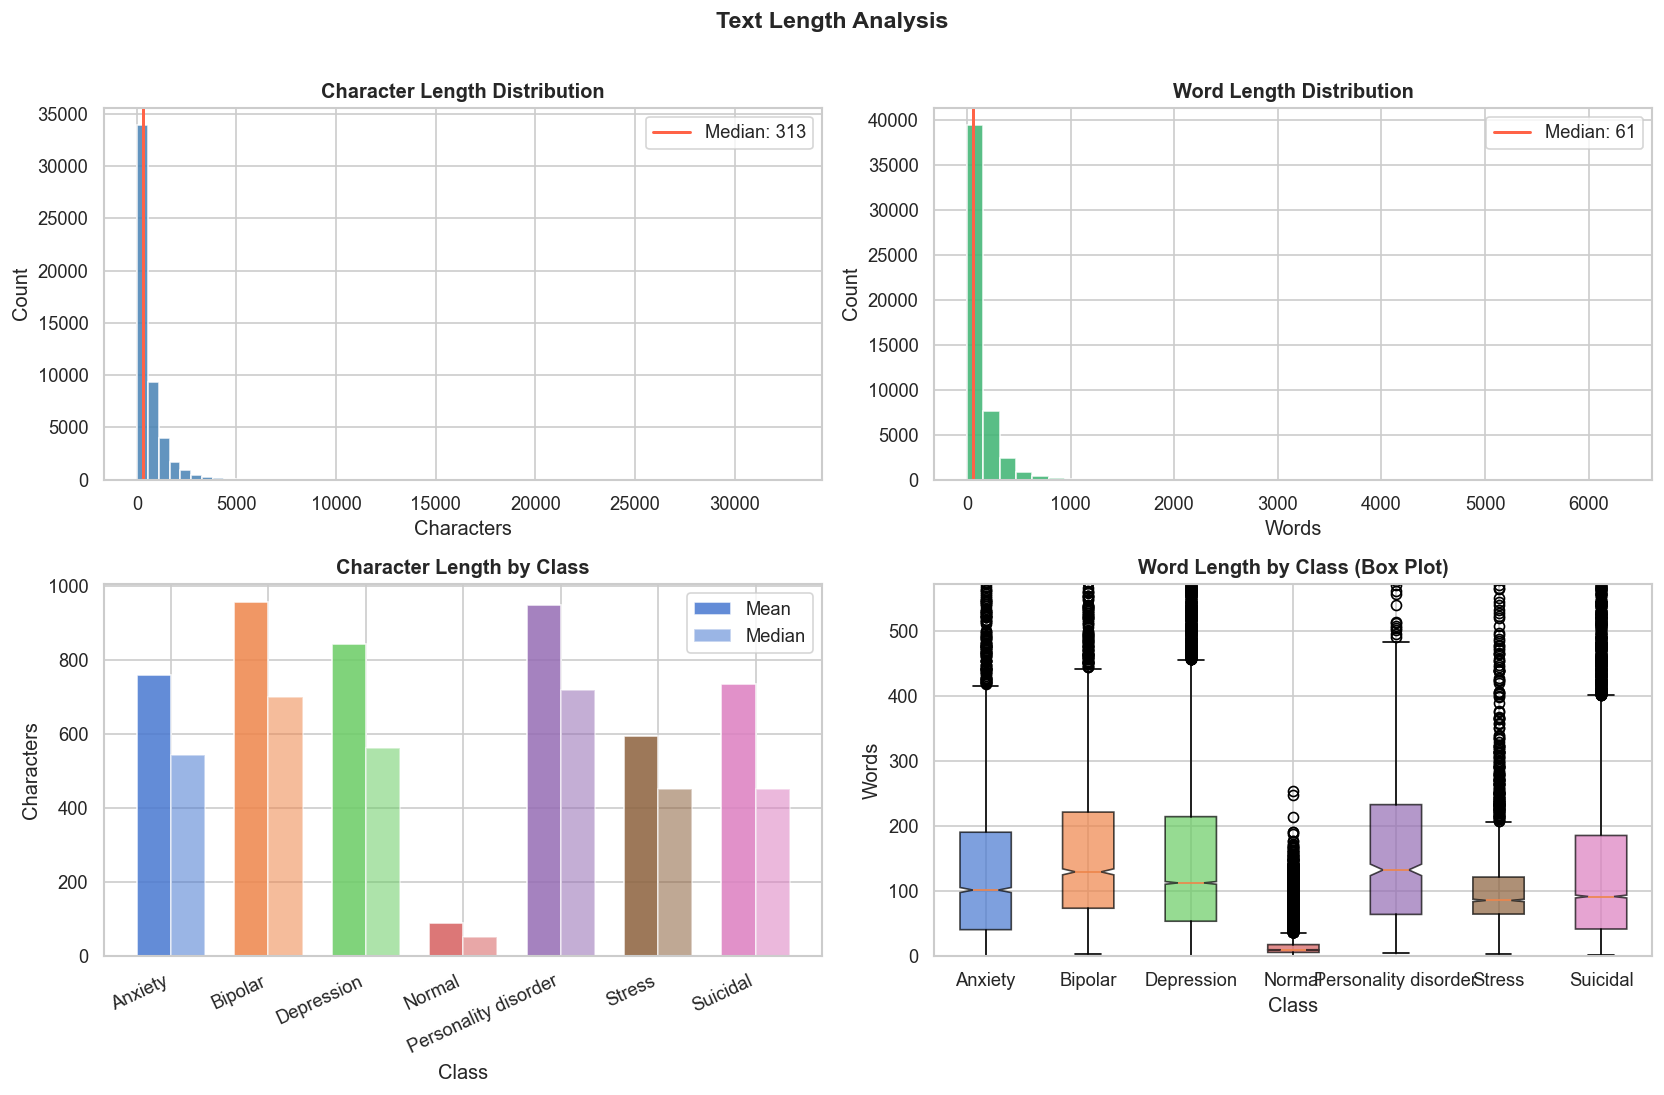

Figure saved → output/text_length_analysis.png


In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Character length — overall
axes[0, 0].hist(df['char_len'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0, 0].axvline(df['char_len'].median(), color='tomato', lw=1.8, label=f'Median: {df["char_len"].median():.0f}')
axes[0, 0].set_title('Character Length Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Characters'); axes[0, 0].set_ylabel('Count'); axes[0, 0].legend()

# Word length — overall
axes[0, 1].hist(df['word_len'], bins=40, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[0, 1].axvline(df['word_len'].median(), color='tomato', lw=1.8, label=f'Median: {df["word_len"].median():.0f}')
axes[0, 1].set_title('Word Length Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Words'); axes[0, 1].set_ylabel('Count'); axes[0, 1].legend()

# Character length per class
# Character length by class — grouped bar chart
char_stats = df.groupby(LABEL_COL)['char_len'].agg(['mean', 'median'])
classes = sorted(df[LABEL_COL].unique())
colors = sns.color_palette('muted', len(classes))

x = np.arange(len(classes))
width = 0.35

# Mean bars
axes[1, 0].bar(
    x - width/2,
    char_stats.loc[classes, 'mean'],
    width,
    label='Mean',
    color=colors,
    alpha=0.85
)

# Median bars (slightly darker)
axes[1, 0].bar(
    x + width/2,
    char_stats.loc[classes, 'median'],
    width,
    label='Median',
    color=colors,
    alpha=0.55
)

axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels([str(c) for c in classes], rotation=25, ha='right')
axes[1, 0].set_title('Character Length by Class', fontweight='bold')
axes[1, 0].set_xlabel('Class')
axes[1, 0].set_ylabel('Characters')
axes[1, 0].legend()



# Word length per class — box plot
classes = df[LABEL_COL].unique()
data_per_class = [df.loc[df[LABEL_COL] == cls, 'word_len'].values for cls in sorted(classes)]
bp = axes[1, 1].boxplot(
    data_per_class,
    labels=[str(c) for c in sorted(classes)],
    patch_artist=True,
    notch=True,
    showfliers=True
)

colors = sns.color_palette('muted', len(classes))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Keep box readable but still show most outliers
upper_limit = df['word_len'].quantile(0.98)
axes[1, 1].set_ylim(0, upper_limit)

axes[1, 1].set_title('Word Length by Class (Box Plot)', fontweight='bold')
axes[1, 1].set_xlabel('Class')
axes[1, 1].set_ylabel('Words')

plt.suptitle('Text Length Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'text_length_analysis.png', bbox_inches='tight')
plt.show()
print('Figure saved → output/text_length_analysis.png')

In [54]:
# BERT coverage analysis — what % of texts fit within MAX_LENGTH tokens?
# (Quick proxy using whitespace-split word count)
coverage = (df['word_len'] <= MAX_LENGTH).mean() * 100
pct_truncated = 100 - coverage
print(f'Estimated coverage at MAX_LENGTH={MAX_LENGTH}: {coverage:.1f}% of samples')
print(f'Estimated truncated texts               : {pct_truncated:.1f}%')
if pct_truncated > 5:
    p95 = int(df['word_len'].quantile(0.95))
    print(f'💡  Consider MAX_LENGTH ≥ {p95} to cover 95% of samples.')

Estimated coverage at MAX_LENGTH=128: 71.4% of samples
Estimated truncated texts               : 28.6%
💡  Consider MAX_LENGTH ≥ 395 to cover 95% of samples.


## 4. Text Cleaning

In [55]:
# ─── Compiled patterns (define once for speed) ────────────────────────────────
_RE_URL     = re.compile(r'https?://\S+|www\.\S+')
_RE_MENTION = re.compile(r'@\w+')
_RE_HASHTAG = re.compile(r'#(\w+)')          # keep word, strip #
_RE_HTML    = re.compile(r'<[^>]+>')
_RE_EMOJI   = re.compile(
    '['
    u'\U0001F600-\U0001F64F'
    u'\U0001F300-\U0001F5FF'
    u'\U0001F680-\U0001F6FF'
    u'\U0001F1E0-\U0001F1FF'
    u'\U00002702-\U000027B0'
    u'\U000024C2-\U0001F251'
    ']+', flags=re.UNICODE)
_RE_REPEAT  = re.compile(r'(.)\1{2,}')       # 'looooove' → 'loove'
_RE_SPACE   = re.compile(r'\s+')


def clean_text(text: str) -> str:
    """Apply a reproducible cleaning pipeline to a single string."""
    text = str(text)
    text = _RE_HTML.sub(' ', text)            # strip HTML tags
    text = _RE_URL.sub('[URL]', text)         # replace URLs
    text = _RE_MENTION.sub('[USER]', text)    # replace @mentions
    text = _RE_HASHTAG.sub(r'\1', text)       # '#word' → 'word'
    text = _RE_EMOJI.sub(' ', text)           # remove emoji
    text = _RE_REPEAT.sub(r'\1\1', text)      # reduce char repetitions
    text = text.lower()                       # lowercase
    text = _RE_SPACE.sub(' ', text).strip()   # normalise whitespace
    return text


# Smoke test
sample = 'Loooove @elonmusk!! Check https://example.com #AI is 🚀🔥 <b>bold</b>'
print('Before:', sample)
print('After :', clean_text(sample))

Before: Loooove @elonmusk!! Check https://example.com #AI is 🚀🔥 <b>bold</b>
After : loove [user]!! check [url] ai is bold


In [56]:
print('Cleaning text …', end=' ')
df['clean_text'] = df[TEXT_COL].apply(clean_text)

# Drop rows that became empty after cleaning
before = len(df)
df = df[df['clean_text'].str.strip() != ''].copy()
df.reset_index(drop=True, inplace=True)
print('done.')
print(f'Rows removed (empty after cleaning): {before - len(df):,}  |  Remaining: {len(df):,}')

Cleaning text … done.
Rows removed (empty after cleaning): 0  |  Remaining: 51,073


In [57]:
# Before / after length comparison
df['clean_char_len'] = df['clean_text'].str.len()
df['clean_word_len'] = df['clean_text'].str.split().str.len()

comparison = pd.DataFrame({
    'Raw chars'  : df['char_len'].describe().round(1),
    'Clean chars': df['clean_char_len'].describe().round(1),
    'Raw words'  : df['word_len'].describe().round(1),
    'Clean words': df['clean_word_len'].describe().round(1),
})
print('Before vs. After Cleaning')
print(comparison.to_string())

# Side-by-side sample
print('\n── Sample rows ──')
for _, row in df.sample(3, random_state=1).iterrows():
    print(f'  RAW  : {str(row[TEXT_COL])[:120]}')
    print(f'  CLEAN: {row["clean_text"][:120]}')
    print()

Before vs. After Cleaning
       Raw chars  Clean chars  Raw words  Clean words
count    51073.0      51073.0    51073.0      51073.0
mean       575.4        573.0      112.7        112.7
std        847.7        839.2      164.1        164.1
min          2.0          2.0        1.0          1.0
25%         79.0         78.0       15.0         15.0
50%        313.0        311.0       61.0         61.0
75%        745.0        743.0      147.0        147.0
max      32759.0      32759.0     6300.0       6300.0

── Sample rows ──
  RAW  : Today, i have come to the sea side for my sister's wedding. There was a lighthouse at the furthest part of the bay. I ju
  CLEAN: today, i have come to the sea side for my sister's wedding. there was a lighthouse at the furthest part of the bay. i ju

  RAW  : Have my body forgotten how to breath properly? I have a constant feeling of tightness in my chest.
No matter how i breat
  CLEAN: have my body forgotten how to breath properly? i have a constant feel

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# Features and target
X = df['clean_text']
y = df['status']

# Encode target labels
le = LabelEncoder()
y = le.fit_transform(y)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert text to TF-IDF vectors
vectorizer = TfidfVectorizer(max_features=5000)  # You can adjust max_features
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train logistic regression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_vec, y_train)

# Predictions
y_pred = clf.predict(X_test_vec)

# Evaluation
print(classification_report(y_test, y_pred, target_names=le.classes_))

                      precision    recall  f1-score   support

             Anxiety       0.85      0.76      0.81       738
             Bipolar       0.90      0.72      0.80       508
          Depression       0.70      0.75      0.73      2989
              Normal       0.87      0.95      0.91      3294
Personality disorder       0.91      0.33      0.48       194
              Stress       0.65      0.42      0.51       454
            Suicidal       0.69      0.67      0.68      2038

            accuracy                           0.78     10215
           macro avg       0.80      0.66      0.70     10215
        weighted avg       0.78      0.78      0.77     10215

